In [17]:
import sympy as sp
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [186]:
def num_unique_factors(n):
    return len(sp.factorint(n))

def num_factors(n):
    return sum(sp.factorint(n).values())


def avg_factors(n):
    return sum([k * p for (p, k) in sp.factorint(n).items()])/sum([k for (_, k) in sp.factorint(n).items()])

In [187]:
ns = [n for n in np.arange(2, 10000)]
df = pd.DataFrame({
    "n": ns,
    "factors": [sp.factorint(n) for n in ns],    
    "num_factors": [num_factors(n) for n in ns],
    "num_unique_factors": [num_factors(n) for n in ns],    
    "avg_factors": [avg_factors(n) for n in ns]
})

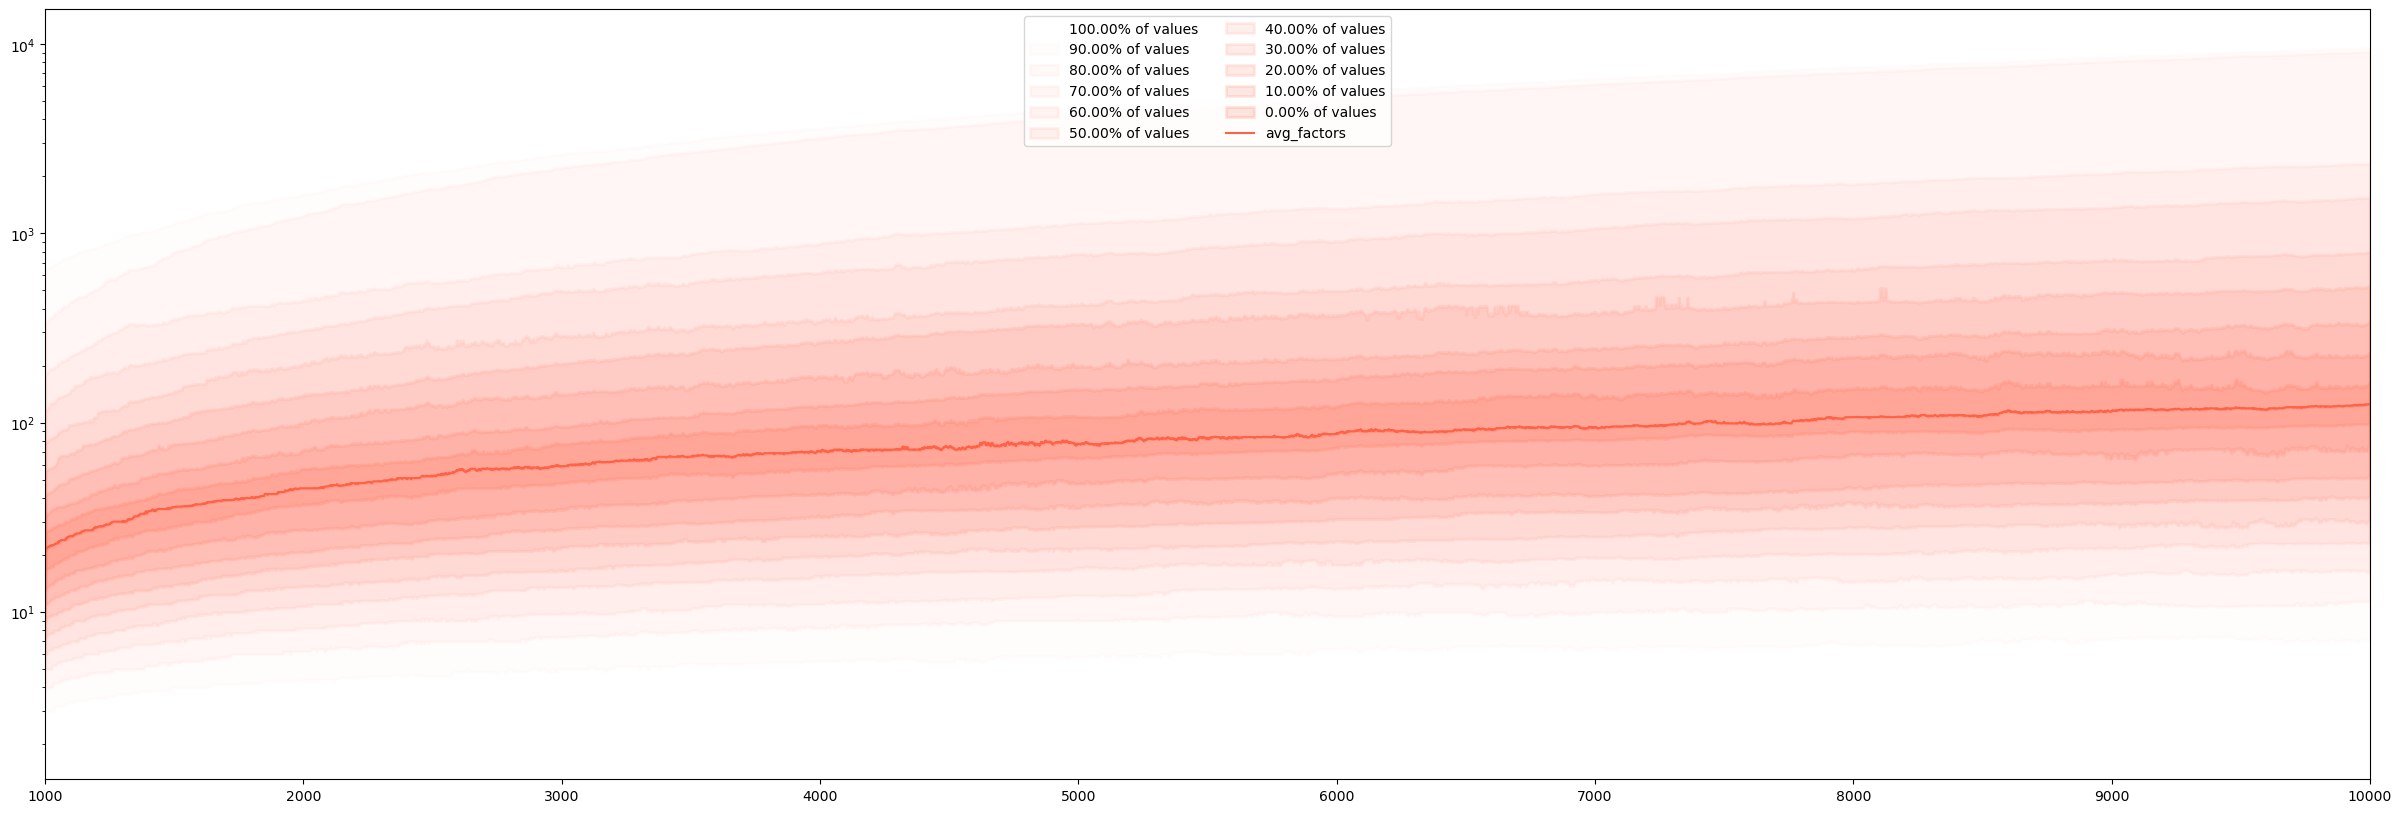

In [259]:
window = 1000
fig, ax = plt.subplots(figsize=(30, 10))
for eps in np.linspace(0.0, 0.5, 11):
    ax.fill_between(df.n, y1=df.avg_factors.rolling(window).quantile(eps), y2=df.avg_factors.rolling(window).quantile(1 - eps), alpha=eps/3, color="tomato", lw=2, label=f"{100*(1-2*eps):3.2f}% of values")

df.avg_factors.rolling(window).quantile(0.5).plot(ax=ax, color="tomato")
ax.set_yscale("log")
ax.set_xlim(window, 10000)
ax.legend(ncols=2, loc="upper center")

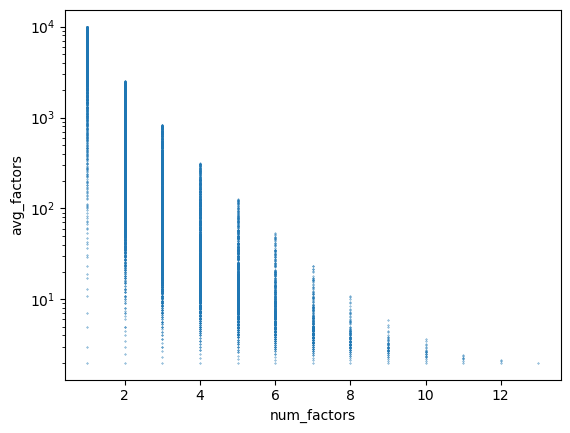

In [261]:
fig, ax = plt.subplots()

df.plot.scatter("num_factors", "avg_factors", s=0.1, ax=ax)
# ax.set_xscale("log")
ax.set_yscale("log")

In [190]:
df

,n,factors,num_factors,num_unique_factors,avg_factors
0,2,{2: 1},1,1,2.000000
1,3,{3: 1},1,1,3.000000
2,4,{2: 2},2,2,2.000000
3,5,{5: 1},1,1,5.000000
4,6,"{2: 1, 3: 1}",2,2,2.500000
...,...,...,...,...,...
9993,9995,"{5: 1, 1999: 1}",2,2,1002.000000
9994,9996,"{2: 2, 3: 1, 7: 2, 17: 1}",6,6,6.333333
9995,9997,"{13: 1, 769: 1}",2,2,391.000000
9996,9998,"{2: 1, 4999: 1}",2,2,2500.500000
